In [1]:
import numpy as np
import torchvision as thv

from utils import Utils
from consts import Consts
from feed_fwd_nn import FeedFwdNN

In [2]:
ds_train = thv.datasets.MNIST(
    root="./data"
    , train=True
    , download=True
    , transform=thv.transforms.Compose(
        [
            thv.transforms.ToTensor()
            , thv.transforms.Normalize(mean=Consts.DS_MEAN, std=Consts.DS_STD)
        ]
    )
)

idx_train = np.random.randint(
    low=0
    , high=ds_train.data.shape[0]
    , size=int(ds_train.data.shape[0] * Consts.DS_SAMPLING_RATIO)
)

X_train = (
    ds_train.data
    .numpy()
    .reshape(-1, Consts.FEATURES_SIZE_IN)
)
    
Y_train = Utils.one_hot_encode(
    X=ds_train.targets.numpy()
    , C=[int(cls[0:1]) for cls in ds_train.classes]
)

print(idx_train.shape)
print(X_train.shape)
print(Y_train.shape)

(60000,)
(60000, 784)
(60000, 10)


In [3]:
ds_val = thv.datasets.MNIST(
    root="./data"
    , train=False
    , download=True
    , transform=thv.transforms.Compose(
        [
            thv.transforms.ToTensor()
            , thv.transforms.Normalize(mean=Consts.DS_MEAN, std=Consts.DS_STD)
        ]
    )
)

idx_val = np.arange(0, int(ds_val.data.shape[0] * Consts.DS_SAMPLING_RATIO))

X_val = (
    ds_val.data
    .numpy()
    .reshape(-1, Consts.FEATURES_SIZE_IN)
)
    
Y_val = Utils.one_hot_encode(
    X=ds_val.targets.numpy()
    , C=[int(cls[0:1]) for cls in ds_val.classes]
)

print(idx_val.shape)
print(X_val.shape)
print(Y_val.shape)

(10000,)
(10000, 784)
(10000, 10)


In [4]:
from linear_layer import LinearLayer
from relu_layer import ReluLayer
from softmax_cross_entropy_layer import SoftmaxCrossEntropyLayer

L1 = LinearLayer(feature_size_in=Consts.FEATURES_SIZE_IN, feature_size_out=Consts.FEATURES_SIZE_OUT)
L2 = ReluLayer(feature_size=Consts.FEATURES_SIZE_OUT)
L3 = SoftmaxCrossEntropyLayer(feature_size=Consts.FEATURES_SIZE_OUT)

for I in Utils.mini_batchify(np.arange(0, 1), 1):
    X, Y = X_train[I], Y_train[I]

    A1 = L1.forward(X)
    A2 = L2.forward(A1)
    A3 = L3.forward(A2, Y)

    dA2 = L3.backward()
    dA1 = L2.backward(dA2)
    dW, db = L1.backward(dA1)

    print("I > dims: {}, shape: {}, value: {}".format(I.ndim, I.shape, I))
    print("X > dims: {}, shape: {}, value: {}".format(X.ndim, X.shape, X))
    print("Y > dims: {}, shape: {}, value: {}".format(Y.ndim, Y.shape, Y))
    print("A1 > dims: {}, shape: {}, value: {}".format(A1.ndim, A1.shape, A1))
    print("A2 > dims: {}, shape: {}, value: {}".format(A2.ndim, A2.shape, A2))
    print("A3 > dims: {}, shape: {}, value: {}".format(A3.ndim, A3.shape, A3))
    print("dA2 > dims: {}, shape: {}, value: {}".format(dA2.ndim, dA2.shape, dA2))
    print("dA1 > dims: {}, shape: {}, value: {}".format(dA1.ndim, dA1.shape, dA1))
    print("dW > dims: {}, shape: {}, value: {}".format(dW.ndim, dW.shape, dW))
    print("db > dims: {}, shape: {}, value: {}".format(db.ndim, db.shape, db))

I > dims: 1, shape: (1,), value: [0]
X > dims: 2, shape: (1, 784), value: [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
  247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
  170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
    0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
   82  56  39   0   0   0   0   0   0 

In [5]:
net1 = FeedFwdNN(
    X_val=X_val
    , Y_val=Y_val
    , idx_val=idx_val
    , lr=Consts.LR
    , X_train=X_train
    , Y_train=Y_train
    , idx_train=idx_train
    , n_epochs=Consts.N_EPOCHS
    , mini_batch_size=Consts.MINI_BATCH_SIZE
)

net1_idps = net1.train_and_validate()

FeedFwdNN.__init__:
	+ n_epochs: 5000
	+ mini_batch_size: 60000
	+ lr: 0.1



100%|██████████| 5000/5000 [1:00:22<00:00,  1.38it/s]


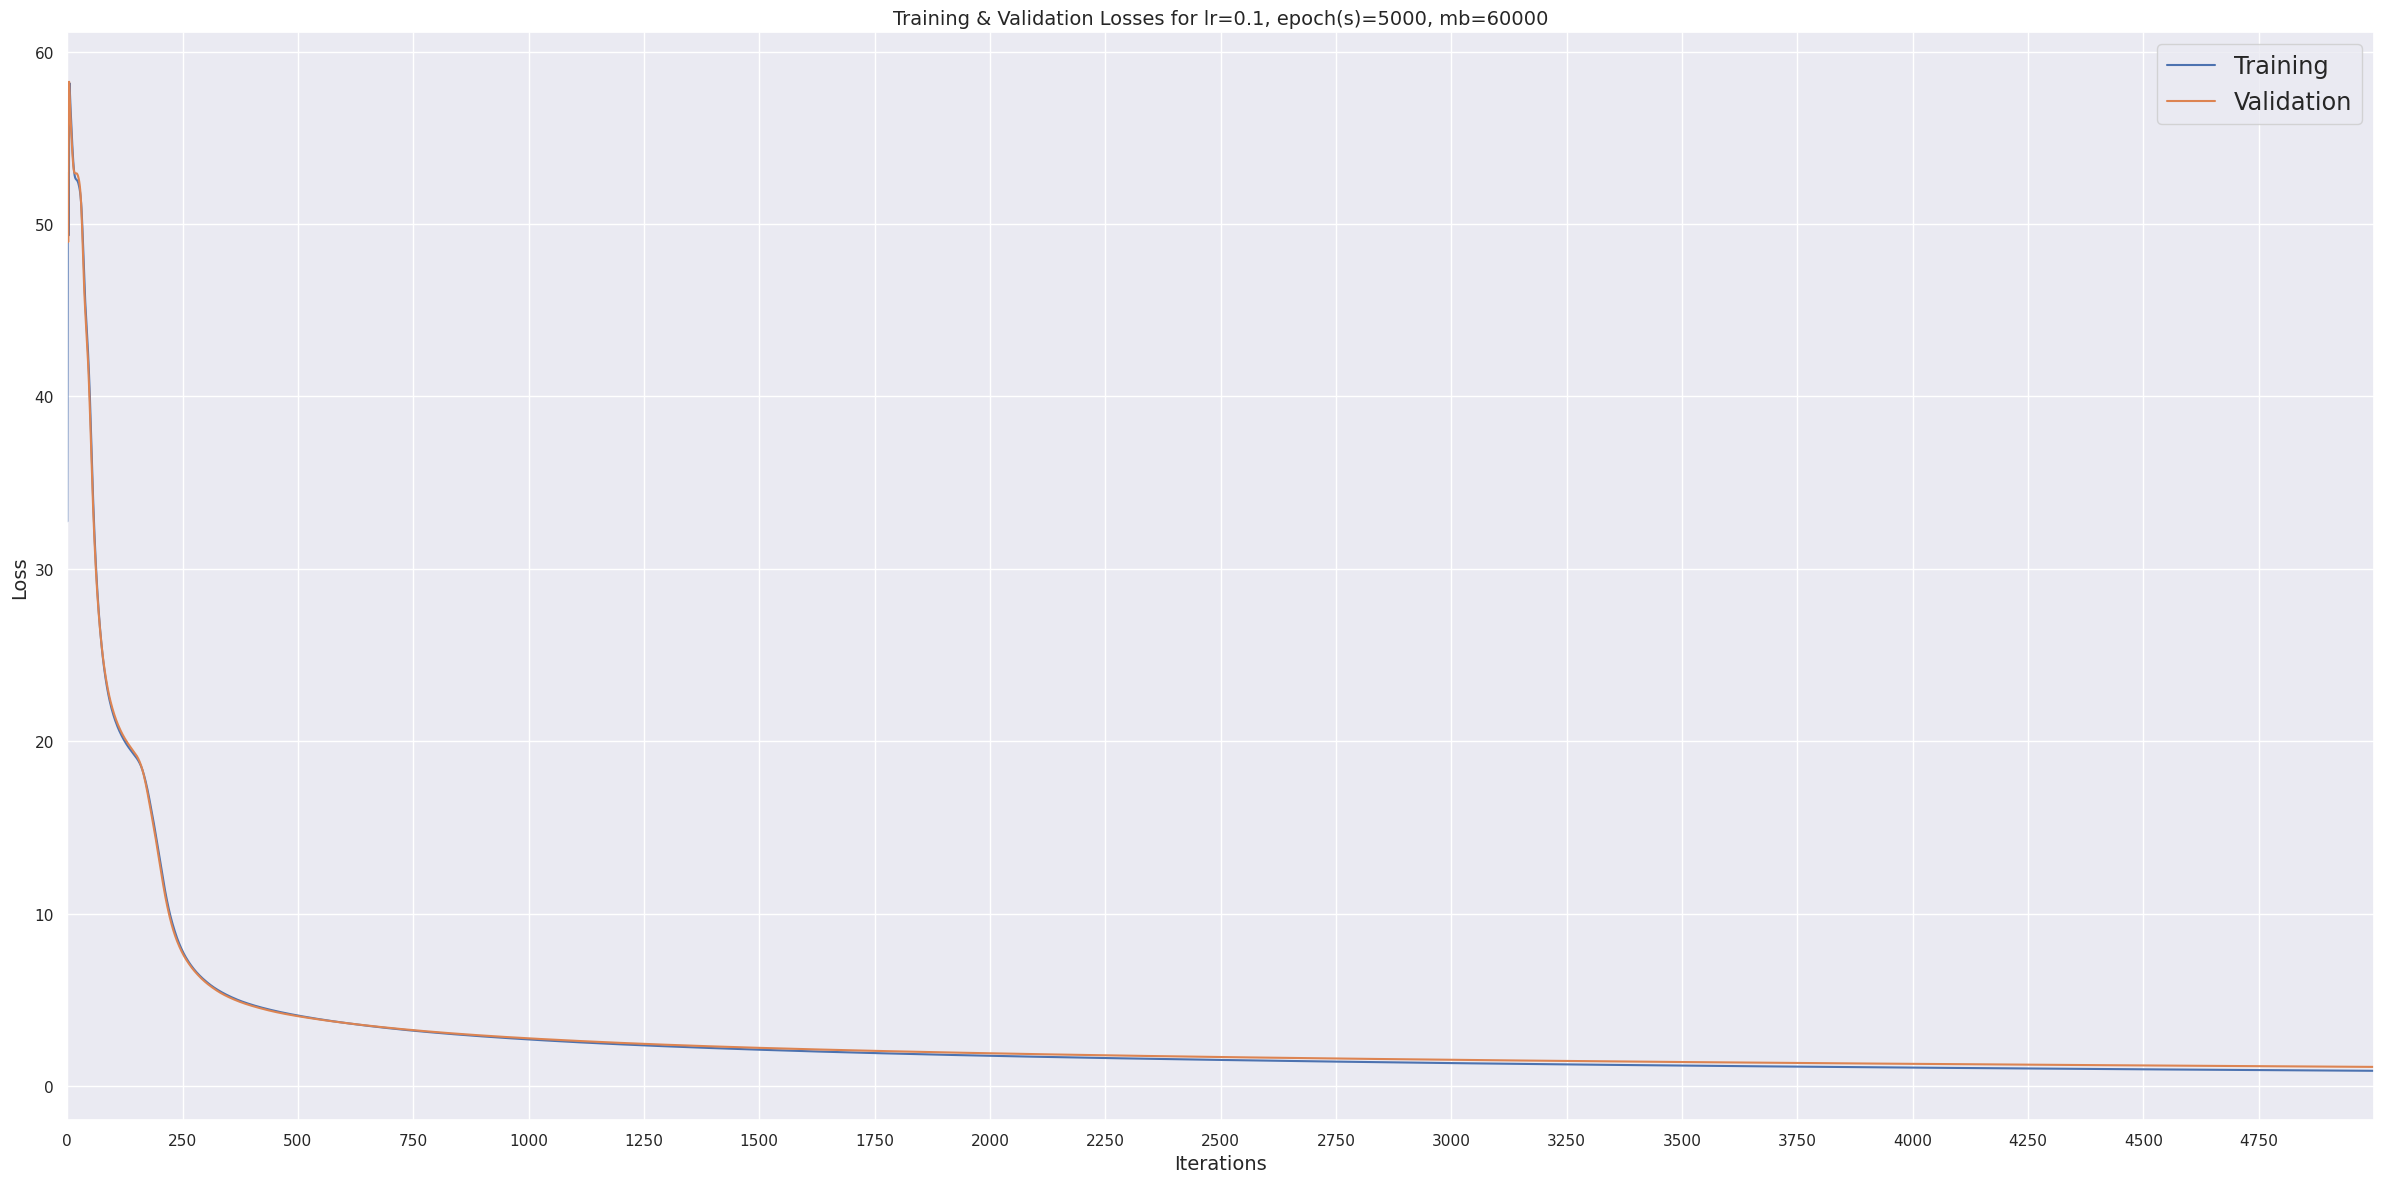

In [6]:
Utils.two_line_plot(
    x_ticks_inc=250
    , y1_legend="Training"
    , y_axis_label="Loss"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[tld.iter_idx for tld in net1_idps]
    , y1=[tld.training_loss for tld in net1_idps]
    , y2=[tld.validation_loss for tld in net1_idps]
    , title=f"Training & Validation Losses for lr={net1.lr}, epoch(s)={net1.n_epochs}, mb={net1.mini_batch_size}"
)

In [7]:
net2 = FeedFwdNN(
    lr=0.01
    , X_val=X_val
    , Y_val=Y_val
    , idx_val=idx_val
    , X_train=X_train
    , Y_train=Y_train
    , idx_train=idx_train
    , n_epochs=Consts.N_EPOCHS
    , mini_batch_size=Consts.MINI_BATCH_SIZE
)

net2_idps = net1.train_and_validate()

FeedFwdNN.__init__:
	+ n_epochs: 5000
	+ mini_batch_size: 60000
	+ lr: 0.01



100%|██████████| 5000/5000 [36:57<00:00,  2.25it/s]


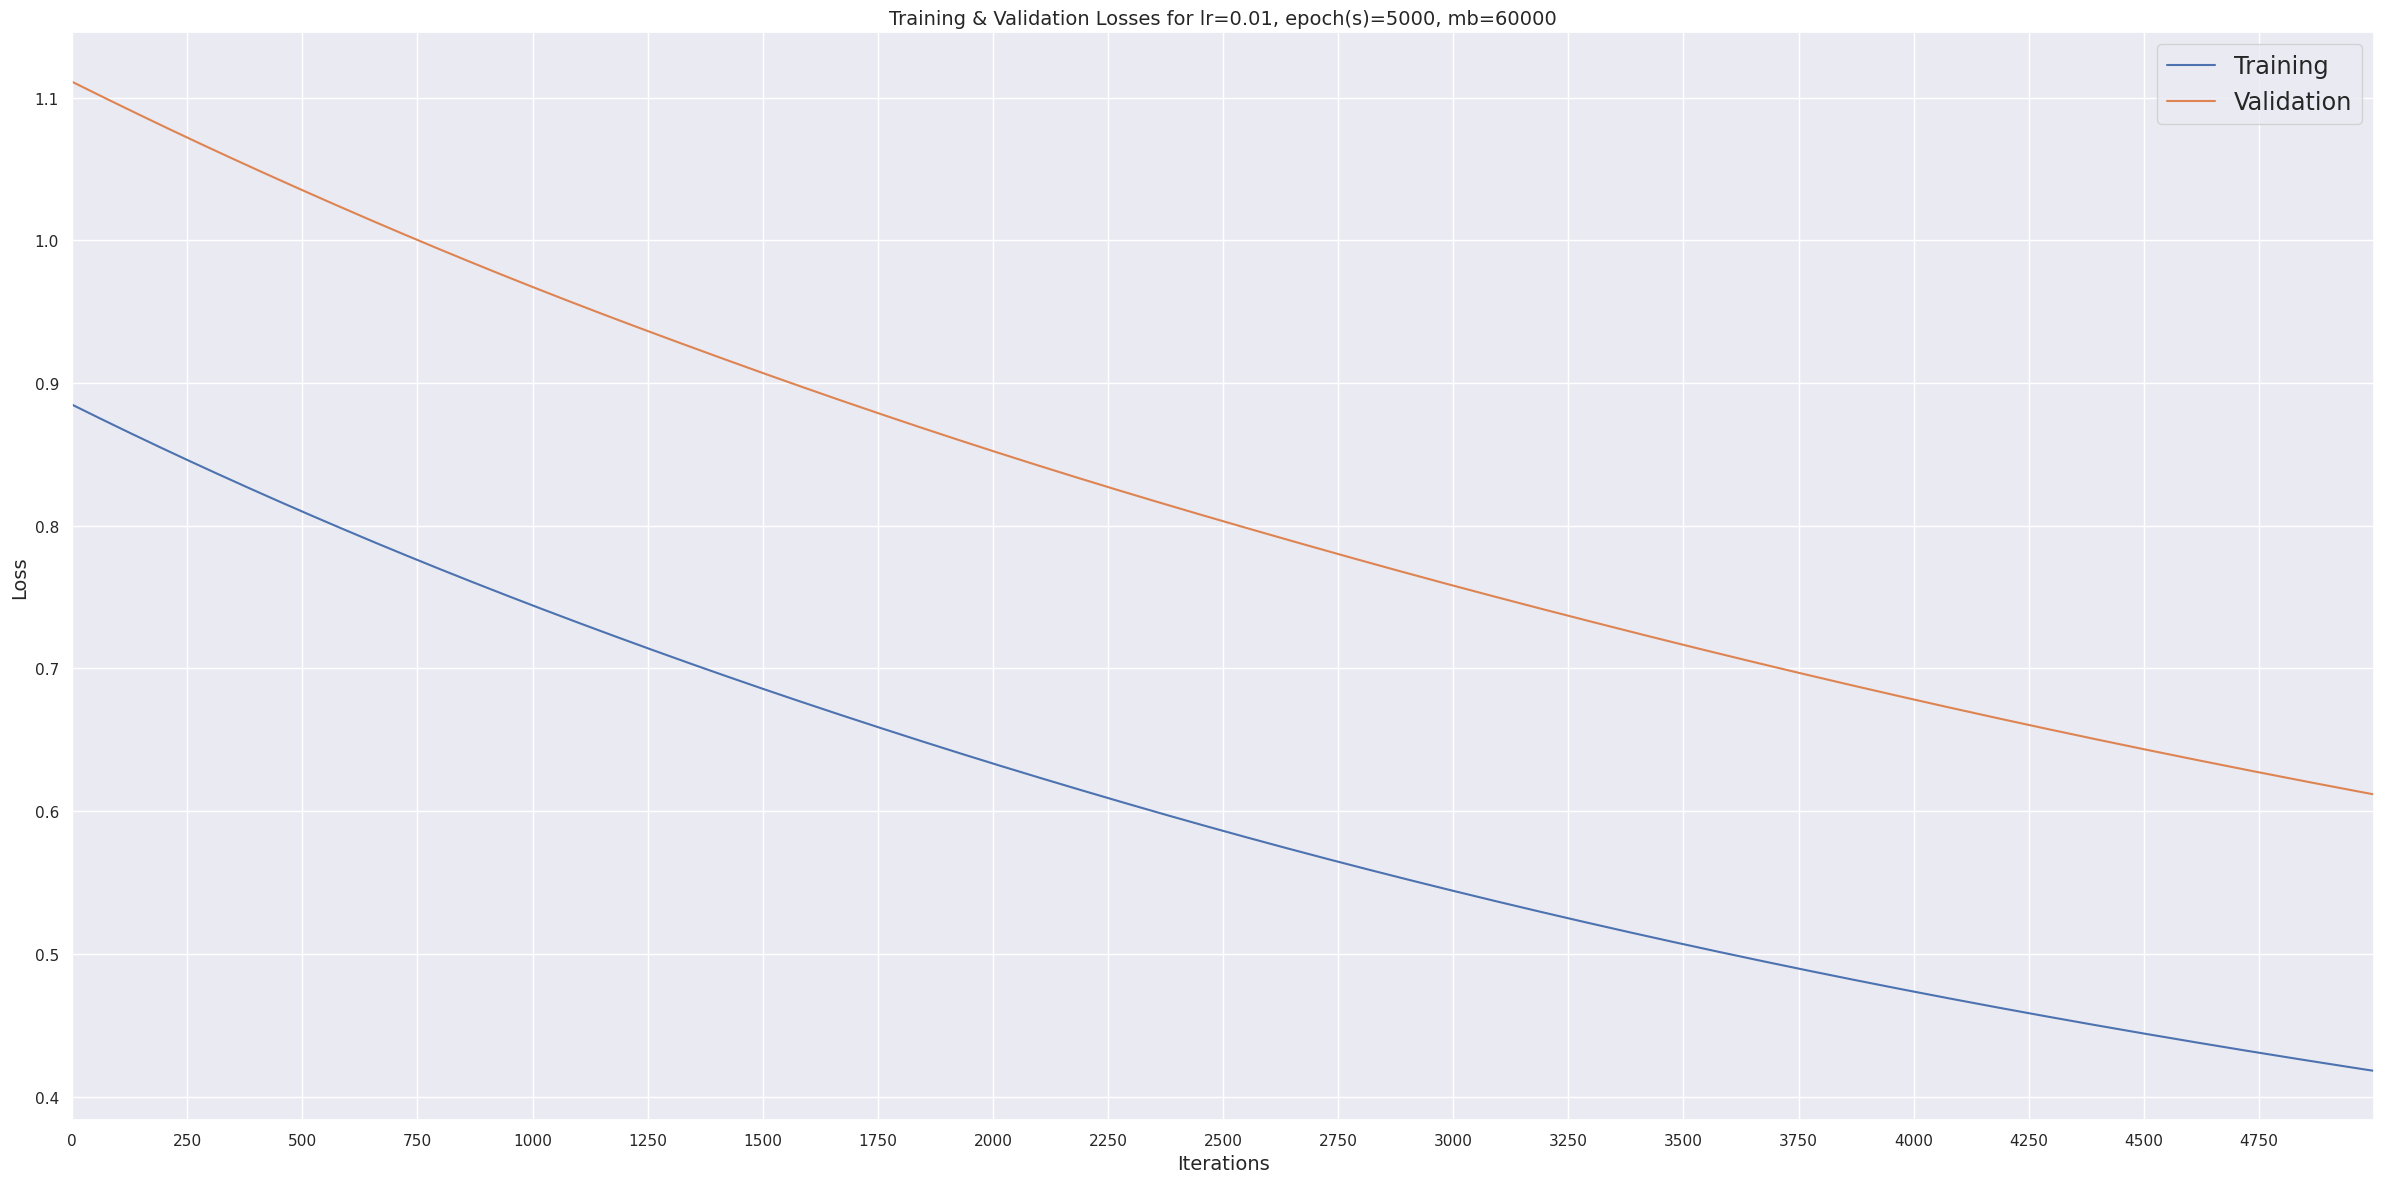

In [8]:
Utils.two_line_plot(
    x_ticks_inc=250
    , y1_legend="Training"
    , y_axis_label="Loss"
    , y2_legend="Validation"
    , x_axis_label="Iterations"
    , fig_size=(2 * 2 * 2 * 3, 2 * 2 * 3)
    , x=[tld.iter_idx for tld in net2_idps]
    , y1=[tld.training_loss for tld in net2_idps]
    , y2=[tld.validation_loss for tld in net2_idps]
    , title=f"Training & Validation Losses for lr={net2.lr}, epoch(s)={net2.n_epochs}, mb={net2.mini_batch_size}"
)

In [9]:
min(net1_idps, key=lambda idp: idp.validation_loss).validation_loss

1.1113557549277622

In [10]:
min(net2_idps, key=lambda idp: idp.validation_loss).validation_loss

0.6117952612250425